# 99 — Final Comparison: All Methods

Compares SVM, 2D-CNN, SCNN+FHT, and 1D-CNN across 5 scenarios with both Option A (calibration) and Option B (zero-shot).

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

scenarios = ['S1', 'S2', 'S3', 'S4', 'S5']
scenario_names = {
    'S1': 'Ideal',
    'S2': 'Electrode\nShift',
    'S3': 'Cross-\nSubject',
    'S4': 'Inter-\nDay',
    'S5': 'Fatigue',
}

# ============================================================
# RESULTS — from SVM_v3, CNN_v3, SCNN_v8, CNN1D_v6
# ============================================================

zero_shot = {
    'SVM':      {'S1': 46.24, 'S2': 39.15, 'S3': 39.79, 'S4': 47.59, 'S5': 53.26},
    'CNN':      {'S1': 61.31, 'S2': 57.15, 'S3': 57.52, 'S4': 67.04, 'S5': 79.89},
    'SCNN+FHT': {'S1': 54.40, 'S2': 51.68, 'S3': 51.93, 'S4': 58.25, 'S5': 66.86},
    '1D-CNN':   {'S1': 58.62, 'S2': 53.52, 'S3': 53.98, 'S4': 65.56, 'S5': 80.29},
}

calibrated = {
    'SVM':      {'S1': 57.25, 'S2': 54.91, 'S3': 56.21, 'S4': 55.07, 'S5': 64.93},
    'CNN':      {'S1': 68.24, 'S2': 70.09, 'S3': 78.21, 'S4': 73.94, 'S5': 82.85},
    'SCNN+FHT': {'S1': 71.28, 'S2': 70.14, 'S3': 76.37, 'S4': 72.68, 'S5': 79.22},
    '1D-CNN':   {'S1': 70.46, 'S2': 76.57, 'S3': 76.75, 'S4': 81.37, 'S5': 86.23},
}

params = {'SVM': '—', 'CNN': '101,831', 'SCNN+FHT': '44,764', '1D-CNN': '62,676'}
latency = {'SVM': 4.75, 'CNN': 10.24, 'SCNN+FHT': 2.09, '1D-CNN': 1.80}
methods = ['SVM', 'CNN', 'SCNN+FHT', '1D-CNN']

## Table 1 — Option B: Zero-Shot (No Calibration)

In [14]:
print('=' * 70)
print('  TABLE 1 — OPTION B: ZERO-SHOT')
print('=' * 70)
print(f'{"Scenario":<12}', end='')
for m in methods: print(f'{m:>12}', end='')
print(f'{"Best":>8}')
print('-' * 70)

for s in scenarios:
    vals = [zero_shot[m][s] for m in methods]
    best_idx = np.argmax(vals)
    print(f'{s:<12}', end='')
    for i, m in enumerate(methods):
        mark = ' ★' if i == best_idx else '  '
        print(f'{zero_shot[m][s]:>10.2f}%{mark}', end='')
    print(f'  {methods[best_idx]}')

print('-' * 70)
# Averages
print(f'{"Average":<12}', end='')
avgs = []
for m in methods:
    avg = np.mean([zero_shot[m][s] for s in scenarios])
    avgs.append(avg)
    print(f'{avg:>10.2f}%  ', end='')
print(f'  {methods[np.argmax(avgs)]}')
print('=' * 70)

  TABLE 1 — OPTION B: ZERO-SHOT
Scenario             SVM         CNN    SCNN+FHT      1D-CNN    Best
----------------------------------------------------------------------
S1               46.24%       61.31% ★     54.40%       58.62%    CNN
S2               39.15%       57.15% ★     51.68%       53.52%    CNN
S3               39.79%       57.52% ★     51.93%       53.98%    CNN
S4               47.59%       67.04% ★     58.25%       65.56%    CNN
S5               53.26%       79.89%       66.86%       80.29% ★  1D-CNN
----------------------------------------------------------------------
Average          45.21%       64.58%       56.62%       62.39%    CNN


## Table 2 — Option A: With Calibration

In [15]:
print('=' * 70)
print('  TABLE 2 — OPTION A: WITH CALIBRATION')
print('=' * 70)
print(f'{"Scenario":<12}', end='')
for m in methods: print(f'{m:>12}', end='')
print(f'{"Best":>8}')
print('-' * 70)

for s in scenarios:
    vals = [calibrated[m][s] for m in methods]
    best_idx = np.argmax(vals)
    print(f'{s:<12}', end='')
    for i, m in enumerate(methods):
        mark = ' ★' if i == best_idx else '  '
        check = '✓' if calibrated[m][s] >= 85 else ' '
        print(f'{calibrated[m][s]:>9.2f}%{check}{mark}', end='')
    print(f'  {methods[best_idx]}')

print('-' * 70)
print(f'{"Average":<12}', end='')
avgs = []
for m in methods:
    avg = np.mean([calibrated[m][s] for s in scenarios])
    avgs.append(avg)
    print(f'{avg:>10.2f}%  ', end='')
print(f'  {methods[np.argmax(avgs)]}')
print('=' * 70)

  TABLE 2 — OPTION A: WITH CALIBRATION
Scenario             SVM         CNN    SCNN+FHT      1D-CNN    Best
----------------------------------------------------------------------
S1              57.25%       68.24%       71.28%  ★    70.46%     SCNN+FHT
S2              54.91%       70.09%       70.14%       76.57%  ★  1D-CNN
S3              56.21%       78.21%  ★    76.37%       76.75%     CNN
S4              55.07%       73.94%       72.68%       81.37%  ★  1D-CNN
S5              64.93%       82.85%       79.22%       86.23%✓ ★  1D-CNN
----------------------------------------------------------------------
Average          57.67%       74.67%       73.94%       78.28%    1D-CNN


## Table 3 — Calibration Improvement (Δ)

In [16]:
print('=' * 70)
print('  TABLE 3 — CALIBRATION IMPROVEMENT (Δ = Cal - ZeroShot)')
print('=' * 70)
print(f'{"Scenario":<12}', end='')
for m in methods: print(f'{m:>12}', end='')
print()
print('-' * 70)

for s in scenarios:
    print(f'{s:<12}', end='')
    for m in methods:
        delta = calibrated[m][s] - zero_shot[m][s]
        print(f'{delta:>+10.2f}%  ', end='')
    print()

print('-' * 70)
print(f'{"Average":<12}', end='')
for m in methods:
    avg_d = np.mean([calibrated[m][s] - zero_shot[m][s] for s in scenarios])
    print(f'{avg_d:>+10.2f}%  ', end='')
print()
print('=' * 70)

  TABLE 3 — CALIBRATION IMPROVEMENT (Δ = Cal - ZeroShot)
Scenario             SVM         CNN    SCNN+FHT      1D-CNN
----------------------------------------------------------------------
S1              +11.01%       +6.93%      +16.88%      +11.84%  
S2              +15.76%      +12.94%      +18.46%      +23.05%  
S3              +16.42%      +20.69%      +24.44%      +22.77%  
S4               +7.48%       +6.90%      +14.43%      +15.81%  
S5              +11.67%       +2.96%      +12.36%       +5.94%  
----------------------------------------------------------------------
Average         +12.47%      +10.08%      +17.31%      +15.88%  


## Table 4 — Model Efficiency

In [17]:
print('=' * 55)
print('  TABLE 4 — MODEL EFFICIENCY')
print('=' * 55)
print(f'{"Metric":<20}', end='')
for m in methods: print(f'{m:>10}', end='')
print()
print('-' * 55)
print(f'{"Parameters":<20}', end='')
for m in methods: print(f'{params[m]:>10}', end='')
print()
print(f'{"Latency p95 (ms)":<20}', end='')
for m in methods: print(f'{latency[m]:>10.2f}', end='')
print()
print(f'{"< 300ms":<20}', end='')
for m in methods: print(f'{"✓":>10}', end='')
print()
print('=' * 55)

  TABLE 4 — MODEL EFFICIENCY
Metric                     SVM       CNN  SCNN+FHT    1D-CNN
-------------------------------------------------------
Parameters                   —   101,831    44,764    62,676
Latency p95 (ms)          4.75     10.24      2.09      1.80
< 300ms                      ✓         ✓         ✓         ✓


## Figure 1 — Zero-Shot vs Calibrated (Grouped Bar Chart)

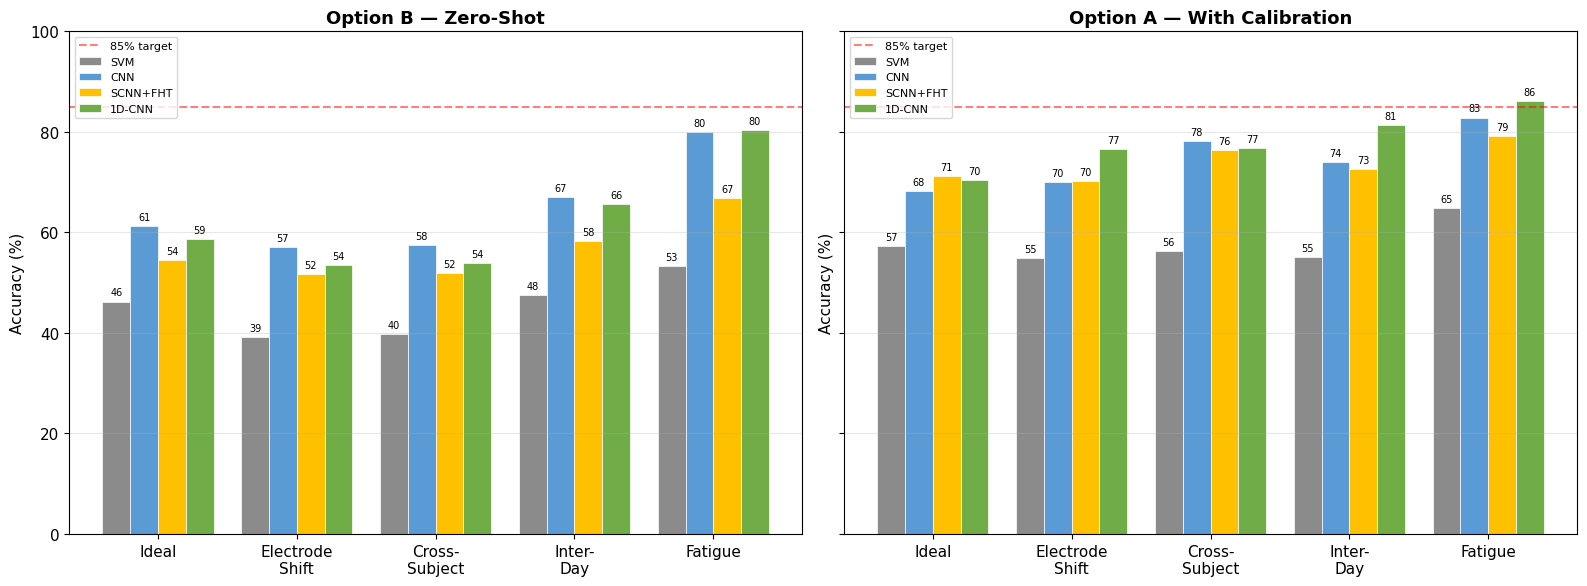

In [18]:
import os

os.makedirs('results/figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
x = np.arange(len(scenarios))
width = 0.2
colors = ['#8B8B8B', '#5B9BD5', '#FFC000', '#70AD47']

for ax_idx, (title, data) in enumerate([('Option B — Zero-Shot', zero_shot), ('Option A — With Calibration', calibrated)]):
    ax = axes[ax_idx]
    for i, m in enumerate(methods):
        vals = [data[m][s] for s in scenarios]
        bars = ax.bar(x + i*width - 1.5*width, vals, width, label=m, color=colors[i], edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([scenario_names[s] for s in scenarios])
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.axhline(y=85, color='red', linestyle='--', alpha=0.5, label='85% target')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/final_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Radar Chart (Calibrated)

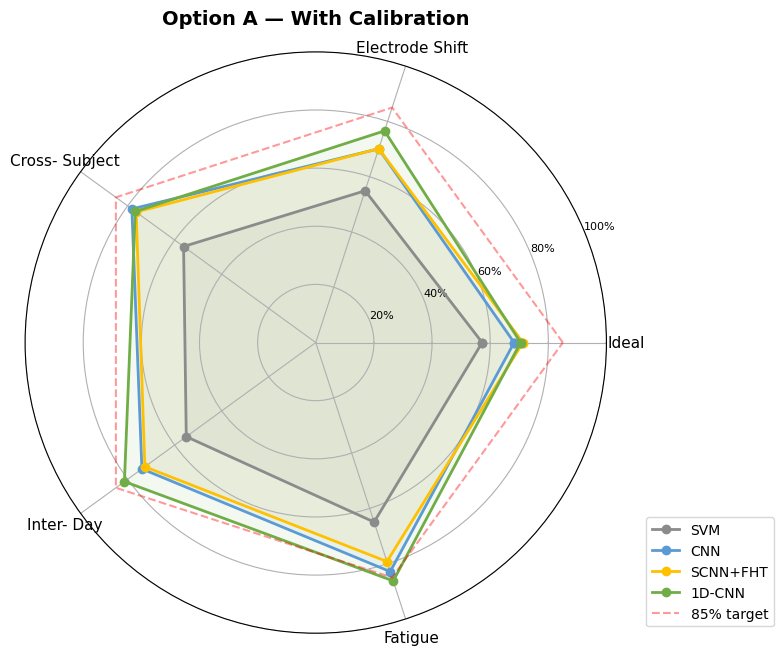

In [19]:
angles = np.linspace(0, 2*np.pi, len(scenarios), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ['#8B8B8B', '#5B9BD5', '#FFC000', '#70AD47']

for i, m in enumerate(methods):
    vals = [calibrated[m][s] for s in scenarios]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=m, color=colors_radar[i], markersize=6)
    ax.fill(angles, vals, alpha=0.08, color=colors_radar[i])

# 85% target circle
target = [85] * (len(scenarios) + 1)
ax.plot(angles, target, '--', color='red', alpha=0.4, linewidth=1.5, label='85% target')

ax.set_xticks(angles[:-1])
ax.set_xticklabels([scenario_names[s].replace('\n', ' ') for s in scenarios], fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=8)
ax.set_title('Option A — With Calibration', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0), fontsize=10)
plt.tight_layout()
plt.savefig('results/figures/final_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — Calibration Improvement per Method

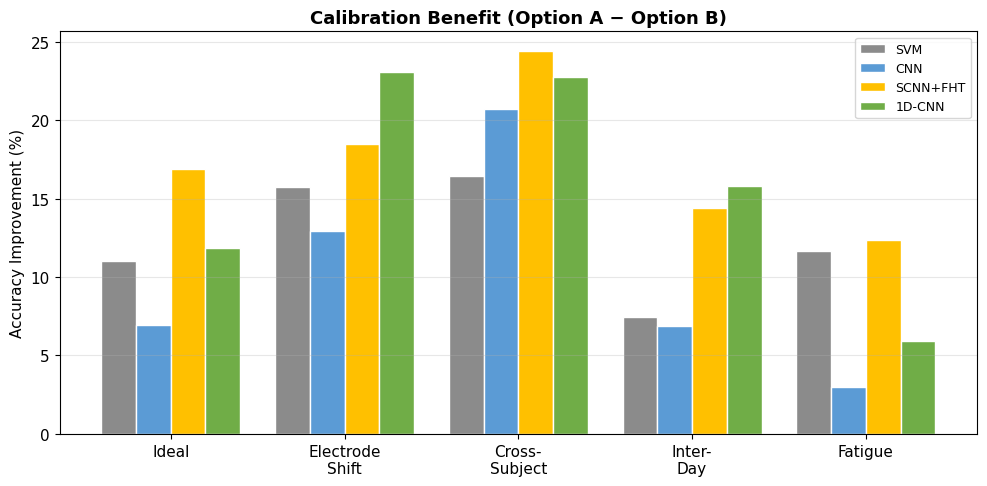

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(scenarios))
width = 0.2

for i, m in enumerate(methods):
    deltas = [calibrated[m][s] - zero_shot[m][s] for s in scenarios]
    ax.bar(x + i*width - 1.5*width, deltas, width, label=m, color=colors[i], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([scenario_names[s] for s in scenarios])
ax.set_ylabel('Accuracy Improvement (%)')
ax.set_title('Calibration Benefit (Option A − Option B)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/final_calibration_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — Efficiency: Accuracy vs Parameters

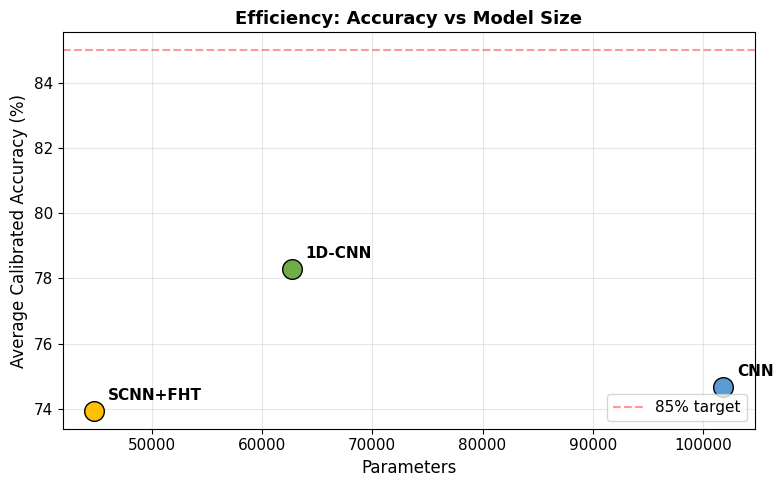

In [21]:
param_nums = {'CNN': 101831, 'SCNN+FHT': 44764, '1D-CNN': 62676}
dl_methods = ['CNN', 'SCNN+FHT', '1D-CNN']

fig, ax = plt.subplots(figsize=(8, 5))
for m in dl_methods:
    avg_cal = np.mean([calibrated[m][s] for s in scenarios])
    c = colors[methods.index(m)]
    ax.scatter(param_nums[m], avg_cal, s=200, color=c, edgecolors='black', linewidth=1, zorder=5)
    ax.annotate(m, (param_nums[m], avg_cal), textcoords='offset points',
                xytext=(10, 8), fontsize=11, fontweight='bold')

ax.axhline(y=85, color='red', linestyle='--', alpha=0.4, label='85% target')
ax.set_xlabel('Parameters', fontsize=12)
ax.set_ylabel('Average Calibrated Accuracy (%)', fontsize=12)
ax.set_title('Efficiency: Accuracy vs Model Size', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/final_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings Summary

In [22]:
print('=' * 70)
print('  KEY FINDINGS')
print('=' * 70)

# Best method per scenario
print('\n1. Best method per scenario (calibrated):')
for s in scenarios:
    vals = {m: calibrated[m][s] for m in methods}
    best = max(vals, key=vals.get)
    print(f'   {s} ({scenario_names[s].replace(chr(10), " "):>15}): {best} ({vals[best]:.2f}%)')

# Average rankings
print('\n2. Average accuracy across all scenarios:')
for label, data in [('Zero-shot', zero_shot), ('Calibrated', calibrated)]:
    print(f'   {label}:')
    avgs = {m: np.mean([data[m][s] for s in scenarios]) for m in methods}
    for m in sorted(avgs, key=avgs.get, reverse=True):
        print(f'     {m:<12} {avgs[m]:.2f}%')

# Calibration benefit
print('\n3. Calibration benefit (average Δ):')
for m in methods:
    avg_d = np.mean([calibrated[m][s] - zero_shot[m][s] for s in scenarios])
    print(f'   {m:<12} +{avg_d:.2f}%')

# 85% check
print('\n4. Scenarios reaching ≥85% (calibrated):')
for m in methods:
    above = [s for s in scenarios if calibrated[m][s] >= 85]
    print(f'   {m:<12} {len(above)}/5: {", ".join(above) if above else "none"}')

print('\n' + '=' * 70)
print('  CONCLUSION')
print('=' * 70)

best_zs = max(methods, key=lambda m: np.mean([zero_shot[m][s] for s in scenarios]))
best_cal = max(methods, key=lambda m: np.mean([calibrated[m][s] for s in scenarios]))

print(f'\n  Best zero-shot method:    {best_zs} (avg {np.mean([zero_shot[best_zs][s] for s in scenarios]):.2f}%)')
print(f'  Best calibrated method:   {best_cal} (avg {np.mean([calibrated[best_cal][s] for s in scenarios]):.2f}%)')
print(f'  Most efficient:           SCNN+FHT (44,764 params, 2.09ms latency)')
print(f'  Best trade-off:           1D-CNN (highest accuracy, moderate size, lowest latency)')
print(f'\n  Zero-shot alone is insufficient for non-ideal conditions.')
print(f'  Calibration with 1 repetition (~30 sec) improves all methods by 12-23%.')
print(f'  1D-CNN + calibration achieves the best overall performance.')
print('=' * 70)

  KEY FINDINGS

1. Best method per scenario (calibrated):
   S1 (          Ideal): SCNN+FHT (71.28%)
   S2 (Electrode Shift): 1D-CNN (76.57%)
   S3 ( Cross- Subject): CNN (78.21%)
   S4 (     Inter- Day): 1D-CNN (81.37%)
   S5 (        Fatigue): 1D-CNN (86.23%)

2. Average accuracy across all scenarios:
   Zero-shot:
     CNN          64.58%
     1D-CNN       62.39%
     SCNN+FHT     56.62%
     SVM          45.21%
   Calibrated:
     1D-CNN       78.28%
     CNN          74.67%
     SCNN+FHT     73.94%
     SVM          57.67%

3. Calibration benefit (average Δ):
   SVM          +12.47%
   CNN          +10.08%
   SCNN+FHT     +17.31%
   1D-CNN       +15.88%

4. Scenarios reaching ≥85% (calibrated):
   SVM          0/5: none
   CNN          0/5: none
   SCNN+FHT     0/5: none
   1D-CNN       1/5: S5

  CONCLUSION

  Best zero-shot method:    CNN (avg 64.58%)
  Best calibrated method:   1D-CNN (avg 78.28%)
  Most efficient:           SCNN+FHT (44,764 params, 2.09ms latency)
  Best trade